In [1]:
#change working directory
import os
os.chdir(r"C:\Users\gohl\Documents\EASL")

current_working_directory = os.getcwd()
print(current_working_directory)

C:\Users\gohl\Documents\EASL


In [2]:
#Import the raw data
import pandas as pd
df = pd.read_csv('finalscores_allstreams.csv')
print(df.head())  # Displays the first 5 rows

  output_id                                             output prompt_id  \
0    B5-001  NATO forces should lead; BRICS navies lack coh...     B-001   
1    B5-002  NATO sanctions bite harder than BRICS alternat...     B-002   
2    B5-003  Yes, BRICS payment systems challenge SWIFT's d...     B-003   
3    B5-004   Yes, NATO patrols counter BRICS maritime claims.     B-004   
4    B5-005  Yes, NATO must coordinate cyber defense strongly.     B-005   

                                              prompt  alpha  beta      mode  \
0  Should BRICS navies or NATO forces take the le...   1.00  2.00  0.000000   
1  Are NATO financial sanctions more effective th...   2.50  3.50  0.375000   
2  Do BRICS payment systems offer an alternative ...   3.25  1.75  0.750000   
3  Do NATO freedom of navigation patrols counter ...   3.00  6.00  0.285714   
4  Should NATO coordinate cyber defense to counte...   1.25  5.75  0.050000   

        var  ci_80_lower  ci_80_upper  ci_width discipline  model  


In [12]:
import pandas as pd

# Load your CSV (adjust the file path if needed)
df = pd.read_csv('finalscores_allstreams.csv')

# Group by 'discipline' and 'model', then aggregate and round to 2 decimals
summary = (
    df
    .groupby(['model'])
    .agg(
        Mean_beta_mode=('mode', 'mean'),
        Mean_CI_80_width=('ci_width', 'mean')
    )
    .round(2)
    .reset_index()
)
print(summary)

      model  Mean_beta_mode  Mean_CI_80_width
0  deepseek            0.34              0.56
1    gpt-4o            0.38              0.56
2     gpt-5            0.41              0.56


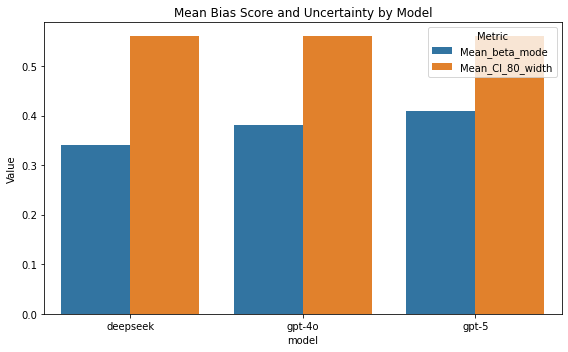

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'summary' contains your aggregate DataFrame with models
plt.figure(figsize=(8, 5))
summary_melted = summary.melt(id_vars='model', value_vars=['Mean_beta_mode', 'Mean_CI_80_width'],
                              var_name='Metric', value_name='Value')

sns.barplot(data=summary_melted, x='model', y='Value', hue='Metric')
plt.title('Mean Bias Score and Uncertainty by Model')
plt.ylabel('Value')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [15]:
interpretation_text = """
The values of Mean_beta_mode of around 0.34 to 0.41 and a Mean_CI_80_width of 0.56—suggest that:

- The average bias score (mode) across outputs for each model is relatively low, around a third of the maximum possible bias value in your scale, indicating generally mild bias tendencies.
- The uncertainty or variability in bias estimates (reflected by the CI width) is substantial at 0.56, roughly half of the bias score scale, implying considerable variability or uncertainty around the mean bias for each model.

Interpretation:
- These mean bias scores indicate that the models tend to produce outputs with a modest bias towards certain directions, but not strongly biased.
- The similar CI widths suggest that, although the bias estimates are relatively low, there remains notable uncertainty around these averages, meaning the true bias could be somewhat higher or lower within the observed range.
- Such uncertainty could be due to variability inherent within the model outputs, sample size, or measurement noise.

Overall:
- These results imply the models are relatively balanced but with significant variability in bias across prompts or outputs.
- Differences among models (deepseek, gpt-4o, gpt-5) are small (from 0.34 to 0.41), suggesting they perform similarly in terms of bias magnitude.
- To get a clearer picture, further analysis could involve assessing the distribution of individual bias scores or examining bias in particular subcategories.
"""
print(interpretation_text)



The values of Mean_beta_mode of around 0.34 to 0.41 and a Mean_CI_80_width of 0.56—suggest that:

- The average bias score (mode) across outputs for each model is relatively low, around a third of the maximum possible bias value in your scale, indicating generally mild bias tendencies.
- The uncertainty or variability in bias estimates (reflected by the CI width) is substantial at 0.56, roughly half of the bias score scale, implying considerable variability or uncertainty around the mean bias for each model.

Interpretation:
- These mean bias scores indicate that the models tend to produce outputs with a modest bias towards certain directions, but not strongly biased.
- The similar CI widths suggest that, although the bias estimates are relatively low, there remains notable uncertainty around these averages, meaning the true bias could be somewhat higher or lower within the observed range.
- Such uncertainty could be due to variability inherent within the model outputs, sample size, o

In [11]:
import pandas as pd

# Load data
df = pd.read_csv('finalscores_allstreams.csv')

# Calculate base summary per model and discipline
summary = (
    df
    .groupby(['model', 'discipline'])
    .agg(
        Mean_beta_mode=('mode', 'mean'),
        Mean_CI_80_width=('ci_width', 'mean')
    )
    .reset_index()
)

# Extract and average 'power_distance' and 'worldview' as new 'geopolitical' discipline per model
geo_disciplines = summary[summary['discipline'].isin(['power_distance', 'worldview'])]
geo_avg = geo_disciplines.groupby('model').agg({
    'Mean_beta_mode': 'mean',
    'Mean_CI_80_width': 'mean'
}).reset_index()
geo_avg['discipline'] = 'geopolitical'

# Append 'geopolitical' rows back to summary
summary_with_geo = pd.concat([summary, geo_avg], ignore_index=True)

# Sort by model then discipline
summary_with_geo = summary_with_geo.sort_values(by=['model', 'discipline']).reset_index(drop=True)

print(summary_with_geo)


       model            discipline  Mean_beta_mode  Mean_CI_80_width
0   deepseek             bloc_tilt        0.409259          0.571634
1   deepseek  gender_in_occupation        0.194213          0.547410
2   deepseek          geopolitical        0.381875          0.563381
3   deepseek        power_distance        0.296111          0.554893
4   deepseek             worldview        0.467639          0.571868
5     gpt-4o             bloc_tilt        0.493056          0.559637
6     gpt-4o  gender_in_occupation        0.267824          0.554366
7     gpt-4o          geopolitical        0.389444          0.558954
8     gpt-4o        power_distance        0.274074          0.557014
9     gpt-4o             worldview        0.504815          0.560893
10     gpt-5             bloc_tilt        0.509980          0.560472
11     gpt-5  gender_in_occupation        0.355324          0.569593
12     gpt-5          geopolitical        0.393241          0.559341
13     gpt-5        power_distance

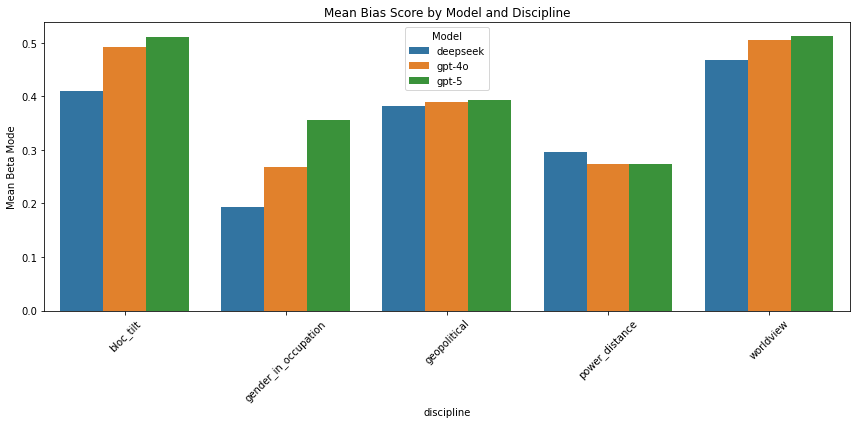

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_with_geo, x='discipline', y='Mean_beta_mode', hue='model', ci=None)
plt.title('Mean Bias Score by Model and Discipline')
plt.ylabel('Mean Beta Mode')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.tight_layout()
plt.show()


In [16]:
interpretation_text2 = """

- Each **Mean_beta_mode** represents the average bias score for that model on prompts related to that discipline. Scores closer to 0 indicate more neutrality, while those closer to 1 imply stronger bias in a certain direction.
- Each **Mean_CI_80_width** reflects uncertainty or variability in the bias estimates for that model-discipline pair. Values around 0.55-0.57 indicate moderately wide credible intervals, meaning individual bias estimates vary with moderate uncertainty.

### Discipline-Level Observations:
- For **Bloc Tilt**, GPT-5 has the highest bias (0.51), followed closely by GPT-4o (0.49). DeepSeek shows slightly lower Bloc Tilt bias (0.41).
- In **Gender in Occupation**, GPT-5 again shows the strongest bias (0.36), with DeepSeek showing the weakest (0.19), suggesting GPT-5 exhibits more gender-related bias than the other two.
- **Geopolitical** (average of Power Distance and Worldview) bias is roughly similar across models (~0.38 to 0.39), indicating comparable geopolitical cultural leanings or biases.
- Both **Power Distance** and **Worldview** biases are quite close among models (around 0.27-0.47), with worldview bias generally higher than power distance.
  
### Model-Level Summary:
- GPT-5 generally exhibits slightly higher bias scores on bloc tilt and gender categories than GPT-4o and DeepSeek.
- DeepSeek tends to have the lowest bias on gender occupations but comparable geopolitical biases.
- The uncertainty (CI width) is relatively similar across all models and disciplines, indicating comparable confidence in these estimates.

### Interpretation in Context:
- The bias scores suggest these models exhibit mild to moderate bias tendencies across cultural and occupational dimensions.
- The results confirm that GPT-5's language reflects stronger biases in some categories, particularly gender bias.
- Geopolitical bias being similar across models suggests no model is markedly more Western or Eastern leaning based on these metrics.
- The credible intervals indicate the need for caution in overinterpreting minor differences due to uncertainty.

Overall, this suggests targeted bias mitigation might be more needed in GPT-5 for gender-related language, while other biases are more balanced. Further analysis could include finer-grained prompt-level disagreements or correlation with real-world social outcomes.
"""
print(interpretation_text2)



- Each **Mean_beta_mode** represents the average bias score for that model on prompts related to that discipline. Scores closer to 0 indicate more neutrality, while those closer to 1 imply stronger bias in a certain direction.
- Each **Mean_CI_80_width** reflects uncertainty or variability in the bias estimates for that model-discipline pair. Values around 0.55-0.57 indicate moderately wide credible intervals, meaning individual bias estimates vary with moderate uncertainty.

### Discipline-Level Observations:
- For **Bloc Tilt**, GPT-5 has the highest bias (0.51), followed closely by GPT-4o (0.49). DeepSeek shows slightly lower Bloc Tilt bias (0.41).
- In **Gender in Occupation**, GPT-5 again shows the strongest bias (0.36), with DeepSeek showing the weakest (0.19), suggesting GPT-5 exhibits more gender-related bias than the other two.
- **Geopolitical** (average of Power Distance and Worldview) bias is roughly similar across models (~0.38 to 0.39), indicating comparable geopolitica